# Physical benchmarks: one-dimensional MOT

In this notebook we benchmark ``atomsmltr`` simulations on simple physical examples. We consider the case of a one-dimensionnal magneto-optical trap, and neglect the effect of fluctuations due to spontaneous emission

## Formulaes and orders of magnitude

### Radiation pressure

We consider radiation pressure for an atom of mass $m$, a laser of wavenumber $k$ and a transition of natural linewidth $\Gamma$. It takes the form: 

$$
F = \hbar k \frac{\Gamma}{2} \frac{s}{1+s},
$$

with $s$ the saturation parameter, given by:

$$
s = \frac{I}{I_\mathrm{sat}} \frac{1}{1 + (2\delta/\Gamma)^2}
$$

where $I_\mathrm{sat}$ is the transition saturation intensity, and $\delta$ the laser detuning with respect to the atomic transition. We consider the limit $s\ll 1$ so that the radiation pressures of independent lasers can be summed up. 

### Doppler friction in a 1D Molasse

Now if we consider two counter-propagating beams, in the limit where $kv \ll \Gamma$, the radiation pressure can be approximated by a friction force :

$$
F_\mathrm{rad, fric} = -m\gamma v
$$

with

$$
\gamma = -\frac{\hbar k^2 }{m} s_0 \frac{2 \delta \Gamma}{\delta^2 + \Gamma^2 / 4} 
$$

where $s_0 = I / I_\mathrm{sat}$.

### Retrieving force with a magnetic gradient

Now we add a magnetic gradient along $x$. We denote $b^\prime$ the gradient and $\mu$ the magnetic moment of the atom in the excited state. We consider that the counter propating beams are $\sigma_\pm$ polarized.

We can then show that the radiation pressure induces a spring-like force :

$$
F_\mathrm{rad, spring} = - \kappa x
$$

where :

$$
\kappa = - k \mu b^\prime s_0 \frac{2 \delta \Gamma}{\delta^2 + \Gamma^2 / 4} 
$$

The corresponding oscillation period is given by $T = 2\pi\sqrt{m/\kappa}$

## Definitions

In [82]:
import numpy as np
import scipy.constants as csts
from scipy.integrate import solve_ivp

def _gamma(k, m, δ, Γ, s):
    return -csts.hbar * k**2 / m * s * δ * Γ / (δ**2 + Γ**2 / 4)

def _kappa(k, μ, b, δ, Γ, s):
    return -k * μ * b * s * δ * Γ / (δ**2 + Γ**2 / 4)

def _T(k, μ, b, δ, Γ, s, m):
    kappa = np.abs(_kappa(k, μ, b, δ, Γ, s))
    return 2 * np.pi * np.sqrt(m / kappa)

def u_th(x0, v0, t, m, gamma, kappa):
    """Theoretical trajectory"""
    def dudt(t, u):
        v, x = u
        dv = - gamma * v - kappa / m * x
        dx = v
        return [dv, dx]
    
    u0 = [v0, x0]
    sol = solve_ivp(dudt, t_span=[t.min(), t.max()], y0=u0, t_eval=t)
    return sol.y

## Simulations

Let's test the above model.

────────
| main |
────────
. Parameters :
  ├── λ : 398.91 nm
  ├── Γ : 2π × 2.89e+07 Hz
  ├── Isat : 59.51 mw/cm²
  ├── Doppler temp. : 6.93e-04 K
  └── lande factor g : 1.035




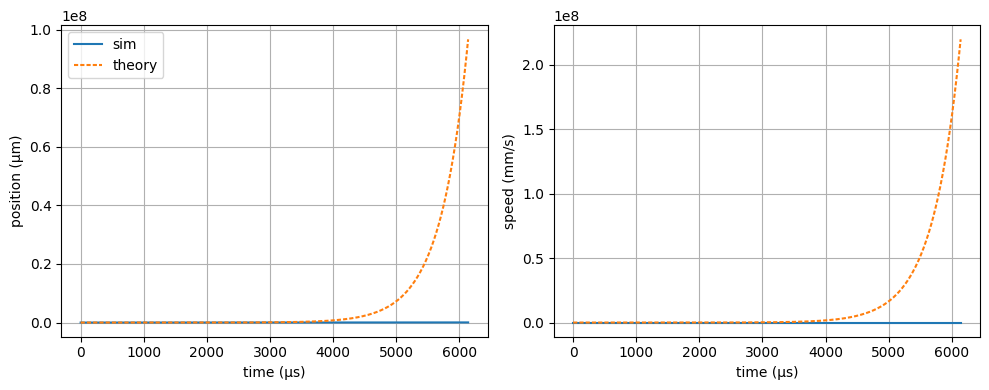

In [ ]:
# - import packages
from atomsmltr.atoms import Ytterbium
from atomsmltr.environment.lasers import PlaneWaveLaserBeam
from atomsmltr.environment.fields import MagneticGradient
from atomsmltr.environment.lasers import CircularRight
from atomsmltr.simulation import Configuration, RK4

import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as csts
from scipy.integrate import solve_ivp

# - settings
atom = Ytterbium()
transition = atom.trans["main"]
transition.print_info()
s = 0.02
b = 0.1  # T/m
delta = -0.5 * transition.Gamma
x0 = 500e-6
v0 = 0

# - compute physical parameters
mu_B = csts.physical_constants["Bohr magneton"][0]
g = transition.lande_factor
μ = g * mu_B
k = transition.k
Γ = transition.Gamma
δ = delta
m = atom.mass
gamma = _gamma(k, m, δ, Γ, s)
kappa = _kappa(k, μ, b, δ, Γ, s)
T = _T(k, μ, b, δ, Γ, s, m)

# - duration
t = np.linspace(0, T, 1_000)

# - init config

# lasers
laser_1 = PlaneWaveLaserBeam(
    wavelength=transition.wavelength,
    direction=(1, 0, 0),
    tag="399+",
    polarization=CircularRight(),
)
laser_2 = PlaneWaveLaserBeam(
    wavelength=transition.wavelength,
    direction=(-1, 0, 0),
    tag="399-",
    polarization=CircularRight(),
)
laser_1.set_power_from_I(s * transition.Isat)
laser_2.set_power_from_I(s * transition.Isat)

# magnetic field
mag_gradient = MagneticGradient(
    origin=(0, 0, 0), slope=b, gradient_direction=(1, 0, 0), field_direction=(1, 0, 0)
)
# config
config = Configuration(atom=atom) + laser_1 + laser_2 + mag_gradient

config.add_atomlight_coupling("399+", "main", detuning=delta)
config.add_atomlight_coupling("399-", "main", detuning=delta)
# simulator
sim = RK4(config)

# - simulate

# simulation parameters
u0 = np.zeros(6)
u0[0] = x0
u0[3] = v0

# run
res = sim.integrate(u0, t)

# - theoretical result
u = u_th(x0, v0, t, m, gamma, kappa)
vt, xt = u

# - plot results
fig, ax = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
ax[0].plot(res.t * 1e6, res.y[0, :] * 1e6, label="sim")
ax[0].plot(res.t * 1e6, xt * 1e6, label="theory", dashes=[2,1])
ax[0].set_ylabel("position (µm)")
ax[0].legend()
ax[1].plot(res.t * 1e6, res.y[3, :] * 1e3)
ax[1].plot(res.t * 1e6, vt * 1e3, dashes=[2,1])
ax[1].set_ylabel("speed (mm/s)")

for cax in ax:
    cax.grid()
    cax.set_xlabel("time (µs)")
plt.show()

Now scan the magnetic field gradient

In [84]:
# - settings
b_list = [0.1, 0.2, 0.5, 1]

sim_list = {}
th_list = {}

# - simulate
for b in b_list:
    # update config
    mag_gradient.slope = b
    config.update_objects(mag_gradient)

    # simulate
    res = sim.integrate(u0, t)
    sim_list[b] = res

    # theory
    gamma = _gamma(k, m, δ, Γ, s)
    kappa = _kappa(k, μ, b, δ, Γ, s)
    th_list[b] = u_th(x0, v0, t, m, gamma, kappa)

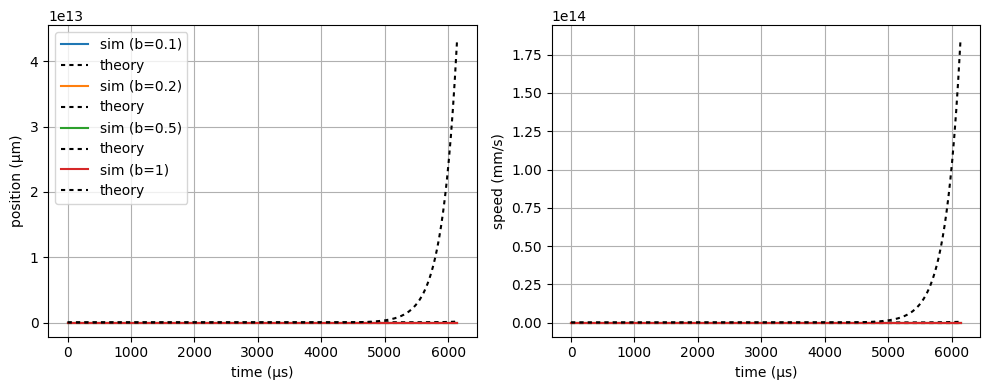

In [85]:
# - plot results
fig, ax = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
for b, res in sim_list.items():
    vt, xt = th_list[b]
    ax[0].plot(res.t * 1e6, res.y[0, :] * 1e6, label=f"sim ({b=})")
    ax[0].plot(res.t * 1e6, xt * 1e6, label="theory", dashes=[2,2], color="k")
    ax[1].plot(res.t * 1e6, res.y[3, :] * 1e3)
    ax[1].plot(res.t * 1e6, vt * 1e3, dashes=[2,2], color="k")

ax[0].set_ylabel("position (µm)")
ax[0].legend()
ax[1].set_ylabel("speed (mm/s)")

for cax in ax:
    cax.grid()
    cax.set_xlabel("time (µs)")
plt.show()